In [63]:
import aqua
from aqua.AQUA_general import AQUA
from aqua.plotting_functions import *

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
# simulation params
T = 200
dt = 0.01
N_iter = int(T/dt)

# RS neuron params
RS = {
    "name": "RS_int",
    "C": 100.0,
    "k": 0.7,
    "v_r": -60.0,
    "v_t": -40.0,
    "v_peak": 35.0,
    "a": 0.03,
    "b": -2.0,
    "c": -50.0,
    "d": 100.0,
    "e": 0.2,
    "f": 150.0,
    "tau": 5.0,
}

FS = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.2, 'f': -200., 'tau': 2.} 

# injected current value
I = 75
I_inj = I * np.ones(N_iter)

x_start = np.array([-60., 0., 0.])
t_start = np.array([0.])

# initialise the batch
neuron = AQUA(FS)
neuron.Initialise(x_start, t_start)

# Run simulation 
X, T, spikes = neuron.update_RK2(dt, N_iter, I_inj)



100%|██████████| 19999/19999 [00:00<00:00, 103309.69it/s]


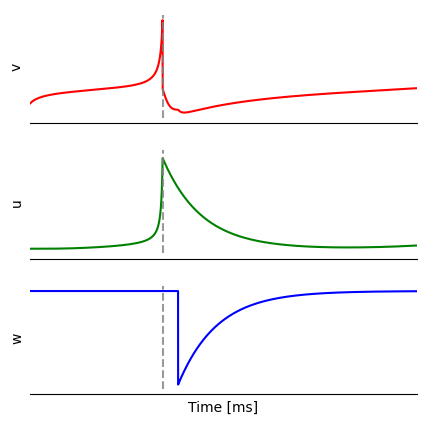

In [ ]:
fig, ax = plt.subplots(3, 1, figsize = (5, 5))

fig, ax = plot_membrane_variables(X, T, [], fig, ax)
sns.despine(fig = fig, top = True, right = True, left = True)

for i in range(3):
    ax[i].vlines(x = spikes[0], ymin = ax[i].get_ylim()[0], ymax = ax[i].get_ylim()[1], linestyle = '--', color = 'gray',
                 alpha = 0.8)
    ax[i].set_xlim((0, 50))
    #ax[i].set_xlim((50, 125))
    ax[i].set_yticks([])
    ax[i].set_xticks([])

ax[0].set_xticks([])
ax[1].set_xticks([])
#ax[-1].set_xlim((75, 125))

#plt.savefig(f"./params_plots/{neuron.name}_single_spike.svg")